In [1]:
from pathlib import Path
from tempfile import TemporaryDirectory

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scarf
from scarf.tools.repack_zarr import repack_store

scarf.configure_output(level='WARNING', progress=True)

In [2]:
dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    name='bastidas-ponce_4K_pancreas-d15_rnaseq',
    destination='scarf_datasets',
    zarr=True,
)

analysis_directory = TemporaryDirectory()
repacked_counts = str(Path(analysis_directory.name) / 'counts.zarr')
repack_store(
    f'{dataset}/data.zarr',
    repacked_counts,
    nthreads=2,
)
ds = scarf.mount_datastore(
    repacked_counts,
    at=str(Path(analysis_directory.name) / 'cell_cycle_analysis.zarr'),
    nthreads=4,
    default_assay='RNA'
)

Downloading bucket files: 43423201 / 43423201 complete

Downloading bytes: 43423201 / 43423201 complete

Repacking RNA/artifacts/reduction//loadings: 1 / 1 complete

Repacking RNA/artifacts/reduction//data: 1 / 1 complete

Repacking RNA/artifacts/connectivity_map//edges: 1 / 1 complete

...

Repacking RNA/artifacts/marker_table//Pre-endocrine/stats: 1 / 1 complete

Repacking RNA/artifacts/marker_table//Ngn3 low EP/stats: 1 / 1 complete

Repacking RNA/artifacts/embedding_initialization//cluster_centers: 1 / 1 complete

Repacking RNA/counts: 1 / 1 complete

  RNA/counts: shape=(3696, 27998), dtype=uint16, chunks=(3696, 13528), shards=(3696, 40584)


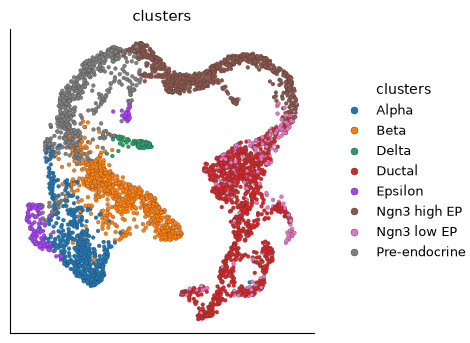

In [3]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='clusters',
)

In [4]:
cell_selection = ds.snapshot_cell_selection("I")
cell_cycle = ds.run_cell_cycle_scoring(cell_selection)
cell_cycle_values = ds.load_artifact(cell_cycle)
s_score = np.asarray(cell_cycle_values["s_score"][:])
g2m_score = np.asarray(cell_cycle_values["g2m_score"][:])
phase = np.asarray(cell_cycle_values["phase"][:]).astype(str)

Calculating feature statistics: 4 / 4 complete

In [5]:
color_key = {
    'G1': 'grey',
    'S': 'salmon',
    'G2M': 'green',
}

umap = ds.cells.to_pandas_dataframe(['RNA_UMAP1', 'RNA_UMAP2'], key='I')
phase_codes = pd.Categorical(phase, categories=['G1', 'S', 'G2M']).codes
plt.scatter(umap['RNA_UMAP1'], umap['RNA_UMAP2'], c=phase_codes, s=3)

In [6]:
pd.crosstab(ds.cells.fetch('clusters'), phase, normalize='index')

col_0,G1,G2M,S
row_0,,,
Alpha,0.960499,0.000000,0.039501
Beta,0.966159,0.000000,0.033841
Delta,0.985714,0.000000,0.014286
Ductal,0.245633,0.191048,0.563319
Epsilon,0.957746,0.000000,0.042254
Ngn3 high EP,0.647975,0.034268,0.317757
Ngn3 low EP,0.412214,0.213740,0.374046
Pre-endocrine,0.932432,0.005068,0.062500


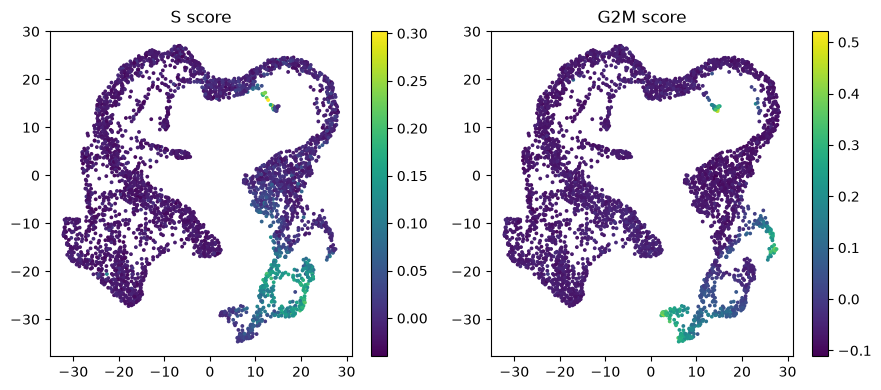

In [7]:
figure, axes = plt.subplots(1, 2, figsize=(9, 4))
for axis, values, title in (
    (axes[0], s_score, 'S score'),
    (axes[1], g2m_score, 'G2M score'),
):
    points = axis.scatter(umap['RNA_UMAP1'], umap['RNA_UMAP2'], c=values, s=3)
    axis.set_title(title)
    figure.colorbar(points, ax=axis)
figure.tight_layout()
figure

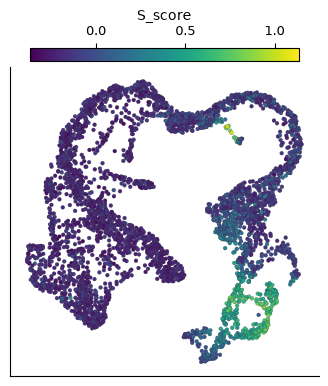

In [8]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='S_score',
)

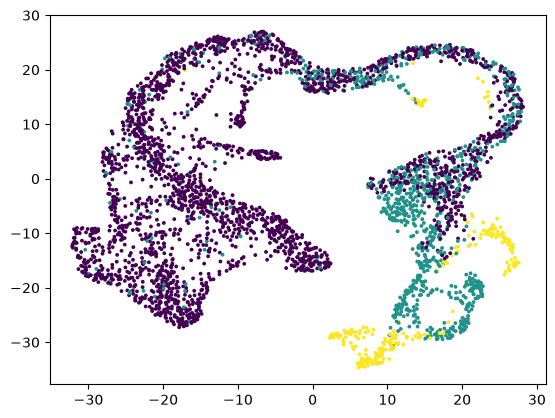

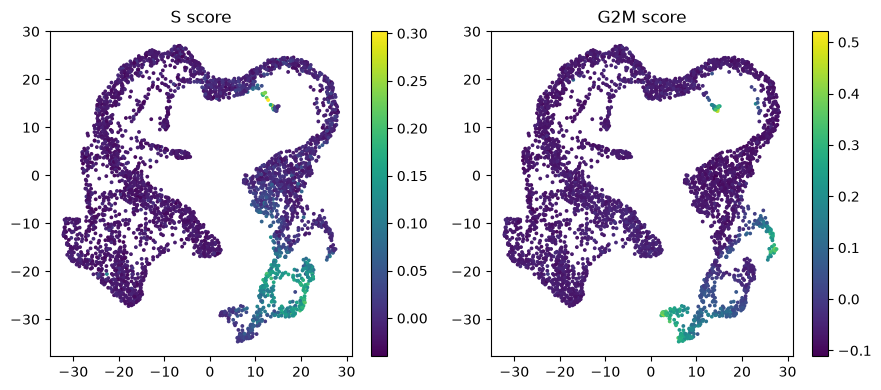

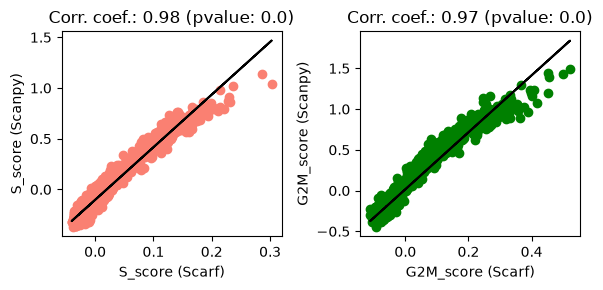

In [9]:
from scipy.stats import linregress

fig, axis  = plt.subplots(1, 2, figsize=(6,3))
for n, (i, x) in enumerate((('S_score', s_score), ('G2M_score', g2m_score))):
    y = ds.cells.fetch(i)
    res = linregress(x, y)
    
    ax = axis[n]
    ax.scatter(x, y, color=color_key[i.split('_')[0]])
    ax.plot(x, res.intercept + res.slope*x, label='fitted line', c='k')
    ax.set_xlabel(f"{i} (Scarf)")
    ax.set_ylabel(f"{i} (Scanpy)")
    ax.set_title(f"Corr. coef.: {round(res.rvalue, 2)} (pvalue: {res.pvalue})")

plt.tight_layout()
plt.show()